# Image to prompt for image generation

Based on the project [Paragraphica](https://bjoernkarmann.dk/project/paragraphica) by Bjoern Karmann.

![Paragraphica by Bjoern Karmann](images/paragraphica_setup.png)

We will use an own input image and extract the necessary information to fill the prompt template above.

- we'll get gps location, time and date from the exif data
- we'll use the gps location to find points of interest in OpenStreetMap
- we'll use the gps location to approximate an address
- we'll use a multimodal model to predict the weather and the temperature based on the image

In [1]:
!pip install exif overpy holidays transformers

  Using cached exif-1.6.1-py3-none-any.whl.metadata (5.2 kB)
  Using cached overpy-0.7-py3-none-any.whl.metadata (3.5 kB)
  Using cached transformers-4.57.2-py3-none-any.whl.metadata (43 kB)
  Using cached plum_py-0.8.7-py3-none-any.whl.metadata (1.5 kB)
  Using cached huggingface_hub-0.36.0-py3-none-any.whl.metadata (14 kB)
  Using cached regex-2025.11.3-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached tokenizers-0.22.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.8 kB)
  Using cached safetensors-0.7.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached hf_xet-1.2.0-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.9 kB)
Using cached exif-1.6.1-py3-none-any.whl (30 kB)
Using cached overpy-0.7-py3-none-any.whl (14 kB)
Using cached transformers-4.57.2-py3-none-any.whl (12.0 MB)
Using cached huggingface_hub-0.36.0-py3-none-any.whl (566 kB)
Using

In [24]:
import glob
from PIL import Image
import exif
import overpy
import holidays

## Load images

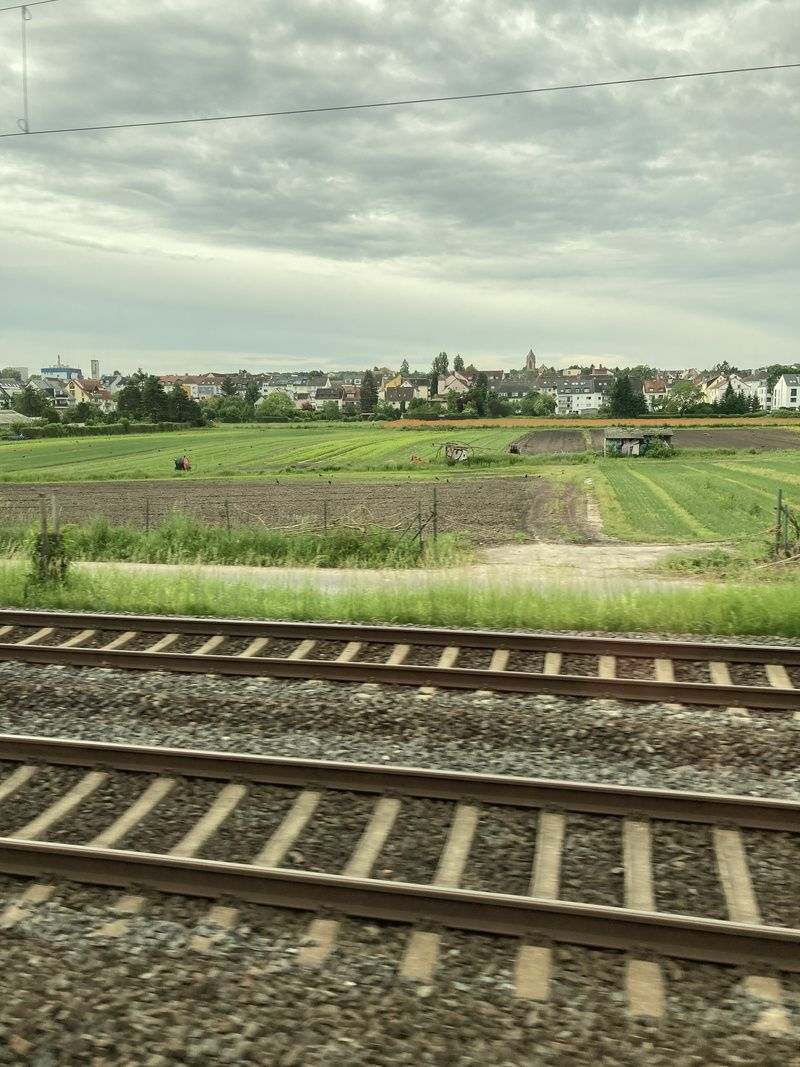

In [3]:
img_path = 'images/IMG_3730_sm.jpg'
img = Image.open(img_path)
img

## Extract Geolocation and Time

In [4]:
def decimal_coords(coords, ref):
    decimal_degrees = coords[0] + coords[1] / 60 + coords[2] / 3600
    if ref == "S" or ref =='W' :
        decimal_degrees = -decimal_degrees
    return decimal_degrees

def image_coordinates(image_path):
    from exif import Image

    with open(image_path, 'rb') as src:
        img = Image(src)
    if img.has_exif:
        try:
            img.gps_longitude
            coords = (decimal_coords(img.gps_latitude,
                      img.gps_latitude_ref),
                      decimal_coords(img.gps_longitude,
                      img.gps_longitude_ref))
        except AttributeError:
            print ('No Coordinates')
    else:
        print ('The Image has no EXIF information')
        
    return({"geolocation_lat":coords[0],"geolocation_lng":coords[1]})

def image_datetime(image_path):
    from exif import Image

    with open(image_path, 'rb') as src:
        img = Image(src)

    # Extract date and time from datetime_original
    if hasattr(img, 'datetime_original'):
        dt_str = img.datetime_original
        try:
            # Split the string into date and time parts
            date_part, time_part = dt_str.split(' ')
            return {
                "date": date_part,
                "time": time_part,
            }
        except (ValueError, AttributeError):
            print("Invalid datetime format")
            return None

In [29]:
lat, lng = image_coordinates(img_path).values()
date, time_of_day = image_datetime(img_path).values()
print(f"location: {lat}, {lng}")
print(f"date and time: {date}, {time_of_day}")

location: 50.10122777777778, 8.719558333333334
date and time: 2024:05:21, 09:15:50


## Special events

In [38]:
import holidays
from datetime import datetime
from dateutil.easter import easter
from dateutil.relativedelta import relativedelta


def is_special_event_germany(date_str):
    """
    Check if a given date string (in format YYYY:MM:DD) is a special event in Germany.

    Args:
        date_str (str): Date in format "YYYY:MM:DD"

    Returns:
        tuple: (is_special, event_name)
    """
    # Parse input string
    try:
        year, month, day = map(int, date_str.split(":"))
        date_to_check = datetime(year, month, day)
    except ValueError:
        raise ValueError("Date must be in format YYYY:MM:DD")

    # Check public holidays (official)
    german_holidays = holidays.Germany()
    if date_to_check in german_holidays:
        return True, f"Public Holiday: {german_holidays[date_to_check]}"

    # Special cultural events
    year = date_to_check.year

    # Carnival / Fasching (Sunday before Ash Wednesday)
    easter_date = easter(year)
    ash_wednesday = easter_date - relativedelta(days=46)  # Ash Wednesday
    carnival_sunday = ash_wednesday - relativedelta(days=1)  # Last Sunday before Ash Wednesday
    if date_to_check == carnival_sunday:
        return True, "Carnival / Fasching"

    # Oktoberfest (typically first weekend of September)
    oktoberfest_start = datetime(year, 9, 16)
    oktoberfest_end = datetime(year, 10, 3)
    if oktoberfest_start <= date_to_check <= oktoberfest_end:
        return True, "Oktoberfest"

    # Christmas markets (start around Nov 1st)
    if (month == 11 and day >= 1) or month == 12:
        return True, "Christmas Market Season"

    # New Year's Eve
    if month == 12 and day == 31:
        return True, "New Year's Eve"

    # Easter Monday (if not already caught by holidays)
    easter_monday = easter_date + relativedelta(days=1)
    if date_to_check == easter_monday:
        return True, "Easter Monday"

    # Other possible events?
    # For example: Tag der Arbeit (May 1st) is already in holidays

    return False, None


# Example usage
# date_input = "2024:05:21"  # May 21, 2024
is_special, event_name = is_special_event_germany(date)

if is_special:
    print(f"{date} is a special event: {event_name}")
    date = f"{date}, {event_name}"
else:
    print(f"{date} is not a special event in Germany.")


2024:05:21 is not a special event in Germany.


## Points of interest (via OpenStreetMap)

In [39]:
def points_of_interest(lat, lng, radius=150, max=5):
    api = overpy.Overpass()

    query = '''[out:json][timeout:25];
    (
       // Regex for the following tags 150m around the point (lat, lon)
       nwr[~"^historic$"~"."](around:{radius},{lat},{lng});
       nwr[~"^amenity$"~"."](around:{radius},{lat},{lng});
       nwr[~"^landuse$"~"."](around:{radius},{lat},{lng});
       nwr[~"^natural$"~"."](around:{radius},{lat},{lng});
       nwr[~"^leisure$"~"."](around:{radius},{lat},{lng});
    );
    out;'''.format(radius=radius, lat=lat, lng=lng)

    res = api.query(query)
    tags = [node.tags for node in res.nodes]
    if len(tags) > max:
        tags = tags[:max]
    return tags

def extract_name_or_amenity(items):
    """
    Extract the 'name' field from each dictionary in the list. If 'name' is not present,
    fall back to the 'amenity' field.

    Args:
        items (list): A list of dictionaries containing location data.

    Returns:
        list: A list of strings containing either the 'name' or 'amenity' values.
    """
    result = []
    for item in items:
        # Try to get 'name' first, if not present get 'amenity'
        name_or_amenity = item.get('name', item.get('amenity'))
        result.append(name_or_amenity)
    return result

poi = points_of_interest(lat, lng, 200, 3)
print(poi)
poi = extract_name_or_amenity(poi)
print(poi)

[{'amenity': 'bicycle_parking', 'bicycle_parking': 'stands', 'capacity': '8', 'check_date': '2023-08-18', 'covered': 'no', 'note:de': '4 Bügel vom Typ Frankfurt'}, {'amenity': 'bicycle_parking', 'bicycle_parking': 'stands', 'capacity': '6', 'covered': 'no', 'note:de': '3 Bügel vom Typ Frankfurt'}, {'amenity': 'restaurant', 'cuisine': 'italian', 'name': 'Pizzeria Al Capone', 'website': 'http://www.pizzeria-alcapone-oberrad.de', 'website:menu': 'http://www.pizzeria-alcapone-oberrad.de/speisekarte.html'}]
['bicycle_parking', 'bicycle_parking', 'Pizzeria Al Capone']


## Address

In [40]:
import overpy
import math

def find_closest_address(latitude, longitude, max_distance=1000):
    """
    Find the closest address to given coordinates using Overpass API.

    Args:
        latitude (float): Latitude of the location.
        longitude (float): Longitude of the location.
        max_distance (int): Maximum distance in meters to search for addresses (default: 1000).

    Returns:
        dict: A dictionary containing the closest address information, or None if no address is found.
    """
    # Initialize Overpass API
    api = overpy.Overpass()

    # Calculate the bounding box around the coordinates
    # Convert meters to degrees (approximately 111,111 meters per degree of latitude)
    lat_degrees = max_distance / 111111.0
    lon_degrees = max_distance / (111111.0 * math.cos(math.radians(latitude)))

    min_lat = latitude - lat_degrees
    max_lat = latitude + lat_degrees
    min_lon = longitude - lon_degrees
    max_lon = longitude + lon_degrees

    # Overpass query to find addresses within the bounding box
    query = f"""
    [out:json];
    (
      node["addr:housenumber"]({min_lat},{min_lon},{max_lat},{max_lon});
      way["addr:housenumber"]({min_lat},{min_lon},{max_lat},{max_lon});
      relation["addr:housenumber"]({min_lat},{min_lon},{max_lat},{max_lon});
    );
    out center;
    """

    try:
        # Execute the query
        result = api.query(query)

        # Calculate distances and find the closest node
        closest_node = None
        min_distance = float('inf')

        for node in result.nodes:
            # Calculate distance in meters using Haversine formula
            distance = haversine_distance(latitude, longitude, node.lat, node.lon)

            if distance < min_distance:
                min_distance = distance
                closest_node = node

        if closest_node:
            # Extract address information
            address = {
                'latitude': closest_node.lat,
                'longitude': closest_node.lon,
                'housenumber': closest_node.tags.get('addr:housenumber'),
                'street': closest_node.tags.get('addr:street'),
                'city': closest_node.tags.get('addr:city'),
                'postcode': closest_node.tags.get('addr:postcode'),
                'country': closest_node.tags.get('addr:country'),
                'distance': min_distance
            }
            return address
        else:
            return None

    except Exception as e:
        print(f"Error querying Overpass API: {e}")
        return None

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the distance between two points on the Earth's surface in meters.

    Args:
        lat1 (float): Latitude of point 1.
        lon1 (float): Longitude of point 1.
        lat2 (float): Latitude of point 2.
        lon2 (float): Longitude of point 2.

    Returns:
        float: Distance in meters.
    """
    # Convert latitude and longitude from degrees to radians
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)

    # Haversine formula
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    distance = 6371000 * c  # Earth's radius in meters

    return distance


closest_address = find_closest_address(lat, lng)

if closest_address:
    address = f"{closest_address['street']} {closest_address['housenumber']}"
    if closest_address['city']:
        address += f" in {closest_address['city']}"
    address = address.replace('None', '').replace('  ', ' ')
    print(address)
    # print("Closest address found:")
    # print(f"Latitude: {closest_address['latitude']}")
    # print(f"Longitude: {closest_address['longitude']}")
    # print(f"House number: {closest_address['housenumber']}")
    # print(f"Street: {closest_address['street']}")
    # print(f"City: {closest_address['city']}")
    # print(f"Postcode: {closest_address['postcode']}")
    # print(f"Country: {closest_address['country']}")
    # print(f"Distance: {closest_address['distance']:.2f} meters")
else:
    print("No address found within the specified distance.")
    address = f"{lat}, {lng}"

Offenbacher Landstraße 311


## Weather and temperature guessing via Image-to-Text

In [41]:
# Load model directly
from transformers import AutoProcessor, AutoModelForVision2Seq

processor = AutoProcessor.from_pretrained("llava-hf/llava-1.5-7b-hf")
model = AutoModelForVision2Seq.from_pretrained("llava-hf/llava-1.5-7b-hf")

/opt/conda/lib/python3.11/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [43]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": img_path},
            {"type": "text", "text": "Continue the following sentence: The weather in the image is"},
        ]
    },
]
inputs = processor.apply_chat_template(
	messages,
	add_generation_prompt=True,
	tokenize=True,
	return_dict=True,
	return_tensors="pt",
).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=40)
weather = processor.decode(outputs[0][inputs["input_ids"].shape[-1]:])
weather = weather.replace('The weather in the image is', '').replace('</s>', '').strip().replace('.', ' ')

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": img_path},
            {"type": "text", "text": "Based on the image guess the temperature in °C. Return just the number."},
        ]
    },
]
inputs = processor.apply_chat_template(
	messages,
	add_generation_prompt=True,
	tokenize=True,
	return_dict=True,
	return_tensors="pt",
).to(model.device)

outputs = model.generate(**inputs, max_new_tokens=40)
temperature = processor.decode(outputs[0][inputs["input_ids"].shape[-1]:])
temperature = temperature.replace('The weather in the image is', '').replace('</s>', '').strip()

In [44]:
print(weather)
print(temperature)

cloudy 
10


## Build the prompt for image generating

In [45]:
prompt = f"A {time_of_day} photo taken at {address}. The weather is {weather} and {temperature} degree. The date is {date}. Near by there is {poi[0]}, {poi[1]} and {poi[2]}."
print(prompt)

A 09:15:50 photo taken at Offenbacher Landstraße 311. The weather is cloudy  and 10 degree. The date is 2024:05:21. Near by there is bicycle_parking, bicycle_parking and Pizzeria Al Capone.
